In [1]:
import os,glob
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error,r2_score
from scipy.stats import pearsonr

# 设置matplotlib库字体的非衬线字体为黑体
plt.rcParams["font.sans-serif"]=["SimHei"]
# 设置matplotlib库字体族为非衬线字体
plt.rcParams["font.family"] = ["WenQuanYi Micro Hei"]

# 数据预处理

In [2]:
pth = r'F:\项目数据\污水处理系统碳源投放优化\小时数据'
os.chdir(pth)

In [11]:
files = glob.glob('流量\\*')
df_list = []
for f in files:
    df_list.append(pd.read_excel(f))
df = pd.concat(df_list,axis=0)
df['日期时间'] = pd.to_datetime(df['日期时间'])
df.set_index('日期时间',inplace=True)
for c in df.columns:
    df[c] = pd.to_numeric(df[c],errors='coerce')
df.to_excel('流量.xlsx')

In [12]:
files = glob.glob('水质\\*')
df_list = []
for f in files:
    df_list.append(pd.read_excel(f))
df = pd.concat(df_list,axis=0)
df['日期时间'] = pd.to_datetime(df['日期时间'])
df.set_index('日期时间',inplace=True)
for c in df.columns:
    df[c] = pd.to_numeric(df[c],errors='coerce')
df.to_excel('水质.xlsx')

In [88]:
f = r'F:\项目数据\污水处理系统碳源投放优化\加药累计流量.xlsx'
df = pd.read_excel(f).iloc[:-1,:]
df['日期时间'] = pd.to_datetime(df['日期时间'])
df.set_index('日期时间',inplace=True)
for c in df.columns:
    df[c] = pd.to_numeric(df[c],errors='coerce')
df.to_excel('加药量.xlsx')

In [3]:
df1 = pd.read_excel('水质.xlsx',index_col='日期时间')
df2 = pd.read_excel('加药量.xlsx',index_col='日期时间')
df3 = pd.read_excel('流量.xlsx',index_col='日期时间')

In [4]:
print(df1.head(3))
print(df2.head(3))
print(df3.head(3))

                       进水COD   进水TP  进水NH3-N    进水TN   出水COD   出水TP  出水NH3-N  \
日期时间                                                                           
2025-01-01 00:00:00  171.201  3.369   43.253  56.253   8.881  0.221    0.008   
2025-01-01 02:00:00  174.295  3.338   43.509  55.771  10.616  0.216    0.006   
2025-01-01 04:00:00  177.408  3.222   43.092  54.463  11.044  0.198    0.015   

                      出水TN  
日期时间                        
2025-01-01 00:00:00  4.774  
2025-01-01 02:00:00  5.762  
2025-01-01 04:00:00  6.394  
            加药累计流量\北池碳源  加药累计流量\南池碳源  加药累计流量\北池PAC  加药累计流量\南池PAC  \
日期时间                                                               
2025-02-09     24547.88    422263.53         55.63      80267.94   
2025-02-10     28423.08    425272.33        716.51      80267.97   
2025-02-11     35943.07    433633.67       1677.35      80596.95   

            加药累计流量\北池PAM  加药累计流量\南池PAM  
日期时间                                    
2025-02-09     308759.73       

<Axes: xlabel='日期时间'>

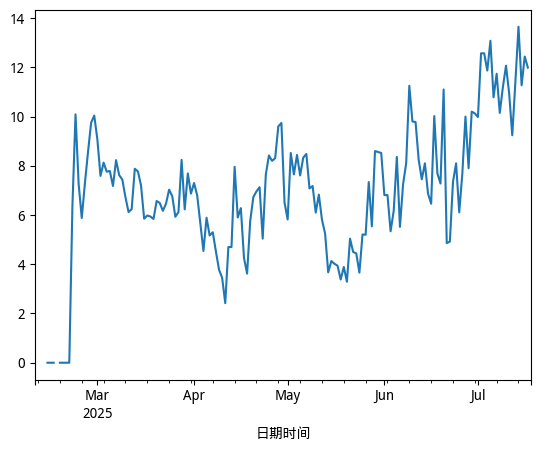

In [5]:
df31 = df3.shift(-1) - df3
df21 = df2.shift(-1) - df2
df21 = df21.mask(df21<0)
df21 = df21.mask(df21>1000)
df21.iloc[:,0].plot()

# 时序匹配

## 流量

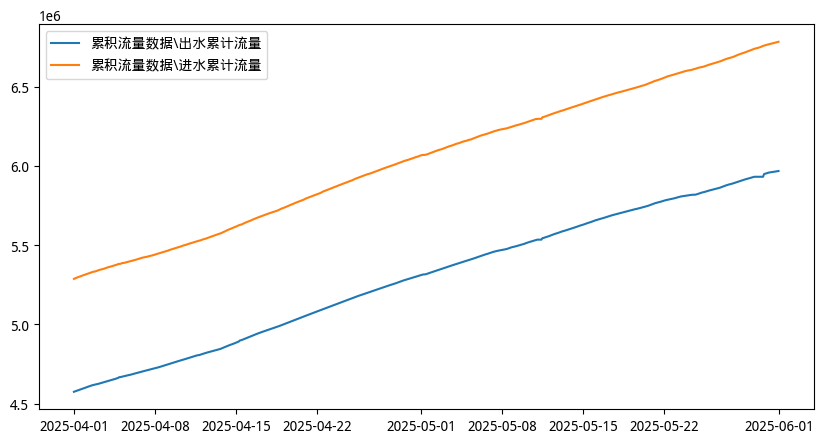

In [6]:
st_date = '2025-04'
ed_date = '2025-05'
fig,axs = plt.subplots(figsize=(10,5))
for c in df3.columns:
    axs.plot(df3.loc[st_date:ed_date,c],label=c)
axs.legend()

(0.0, 5000.0)

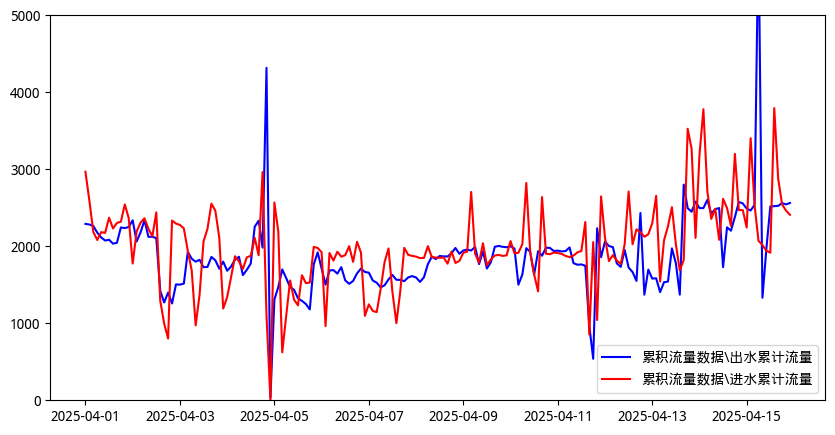

In [7]:
st_date = '2025-04-01'
ed_date = '2025-04-15'
fig,axs = plt.subplots(figsize=(10,5))
color_list = ['blue','red']
for i,c in enumerate(df31.columns):
    axs.plot(df31.loc[st_date:ed_date,c],label=c,c=color_list[i])
axs.legend()
axs.set_ylim(0,5000)

PearsonRResult(statistic=0.8380286025879611, pvalue=0.0)


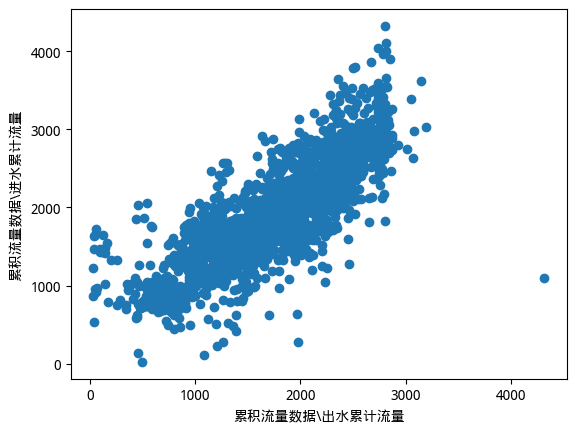

In [8]:
df32 = df31[(df31.iloc[:,0]>0)&((df31.iloc[:,0]<5000))&(df31.iloc[:,1]>0)&((df31.iloc[:,1]<5000))]
plt.scatter(df32.iloc[:,0],df32.iloc[:,1])
plt.xlabel(df32.columns[0])
plt.ylabel(df32.columns[1])
print(pearsonr(df32.iloc[:,0],df32.iloc[:,1]))

## 进出水

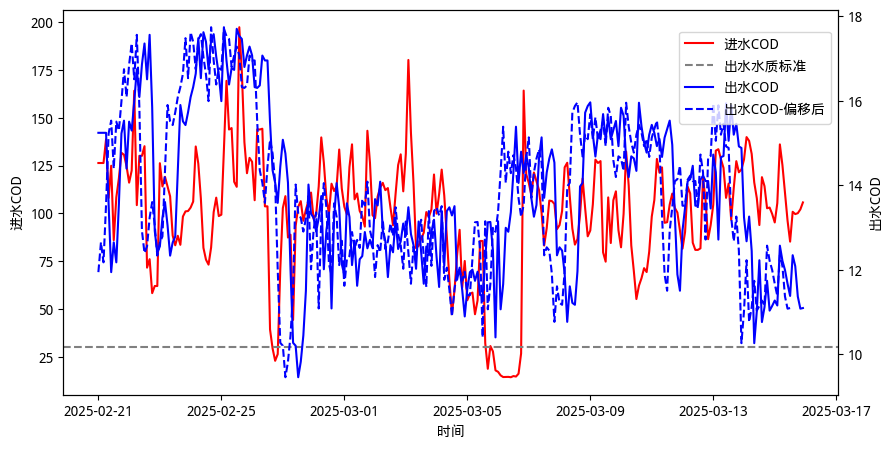

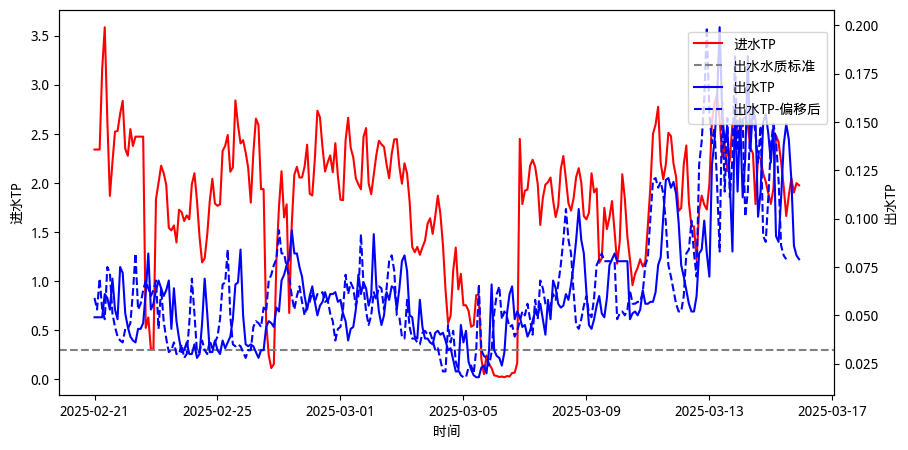

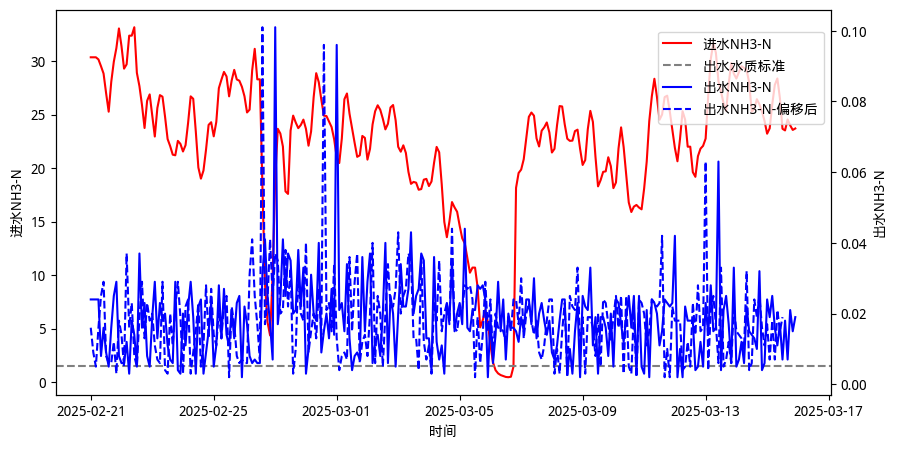

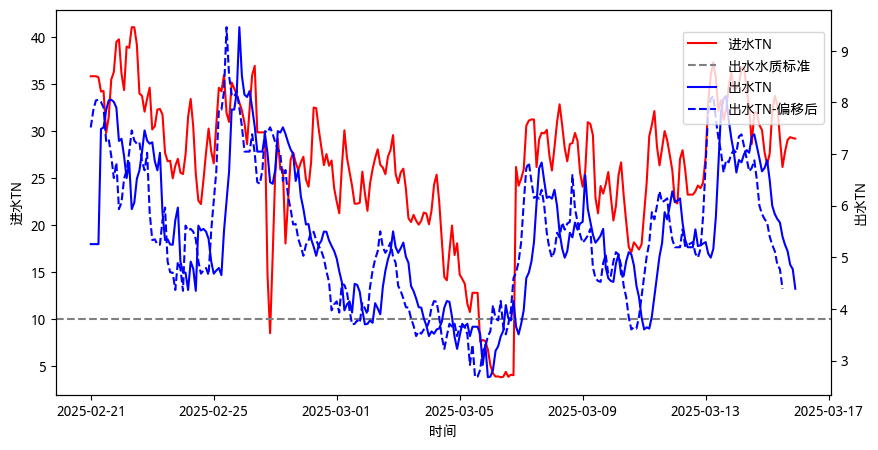

In [14]:
st_date = '2025-02-21'
ed_date = '2025-03-15'
df11 = df1.loc[st_date:ed_date,:]
df12 = df11.copy()
for c in df21.columns:
    if '出水' in c:
        df12[c] = df12[c].shift(-5)

st_v = [30,0.3,1.5,10]
for i,zb in enumerate(['COD','TP','NH3-N','TN']):
    fig,ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(df11[f"进水{zb}"],c='r',label=f"进水{zb}")           
    ax1.axhline(st_v[i],ls='--',c='gray',label='出水水质标准')
#     ax1.set_ylim(df11[f"进水{zb}"].min()*0.5,df11[f"进水{zb}"].max()*1.5)
    ax1.set_ylabel(f"进水{zb}")
    ax1.set_xlabel('时间')
    
    ax2 = ax1.twinx()
    ax2.plot(df11[f"出水{zb}"],c='b',label=f"出水{zb}")
    ax2.plot(df12[f"出水{zb}"],c='b',label=f"出水{zb}-偏移后",ls='--')
    ax2.set_ylabel(f"出水{zb}")
#     ax2.plot(df21.loc[st_date:ed_date,'加药累计流量\北池碳源'],c='green',ls='--')
#     ax2.set_ylabel(f"出水{zb}&加药量")
#     ax2.set_ylabel(df31.columns[0])
    fig.legend(bbox_to_anchor=(0.9, 0.85))  
    
    fig.savefig(f"时间偏移{zb}")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_24408\3273820825.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df11[c] = df11[c].shift(-5)


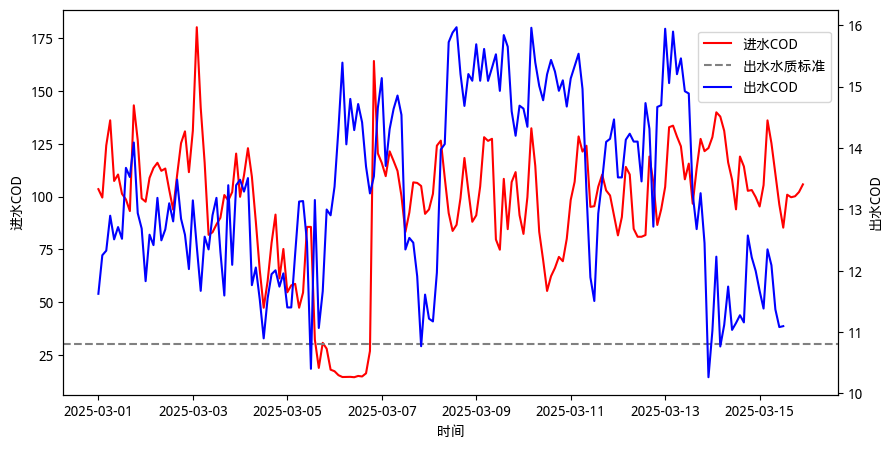

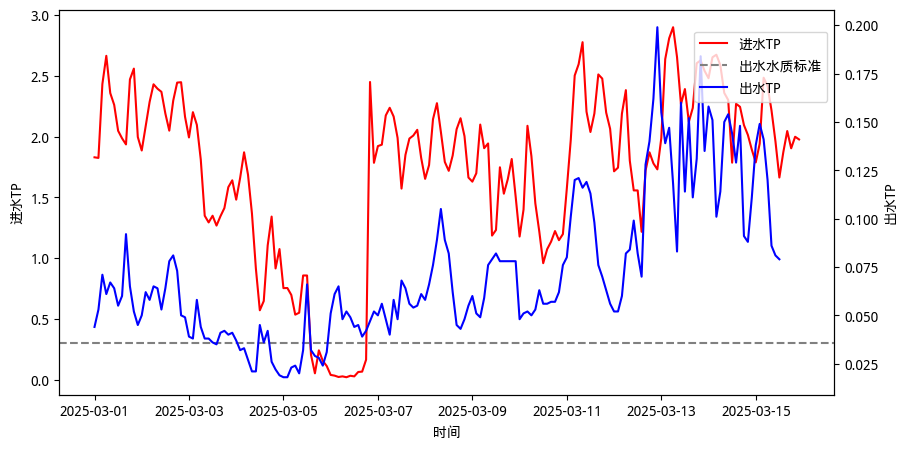

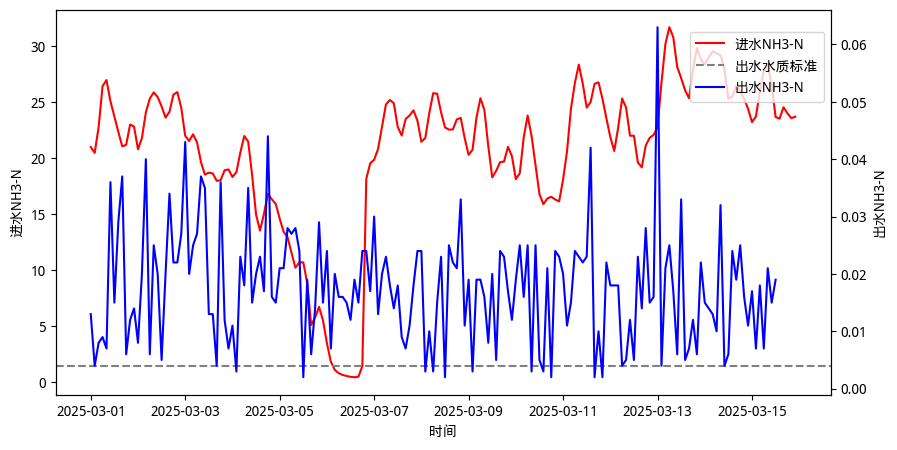

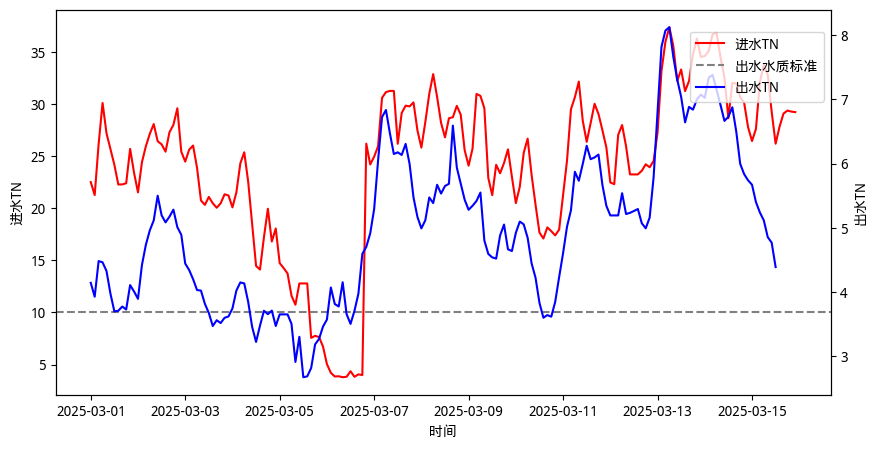

In [10]:
st_date = '2025-03-01'
ed_date = '2025-03-15'
df11 = df1.loc[st_date:ed_date,:]
for c in df11.columns:
    if '出水' in c:
        df11[c] = df11[c].shift(-5)

st_v = [30,0.3,1.5,10]
for i,zb in enumerate(['COD','TP','NH3-N','TN']):
    fig,ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(df11[f"进水{zb}"],c='r',label=f"进水{zb}")           
    ax1.axhline(st_v[i],ls='--',c='gray',label='出水水质标准')
#     ax1.set_ylim(df11[f"进水{zb}"].min()*0.5,df11[f"进水{zb}"].max()*1.5)
    ax1.set_ylabel(f"进水{zb}")
    ax1.set_xlabel('时间')
    
    ax2 = ax1.twinx()
    ax2.plot(df11[f"出水{zb}"],c='b',label=f"出水{zb}")
    ax2.set_ylabel(f"出水{zb}")
#     ax2.plot(df21.loc[st_date:ed_date,'加药累计流量\北池碳源'],c='green',ls='--')
#     ax2.set_ylabel(f"出水{zb}&加药量")
#     ax2.set_ylabel(df31.columns[0])
    fig.legend(bbox_to_anchor=(0.9, 0.85))  
    
#     fig.savefig('偏移-5_{zb}.jpg')

### 互相关确定滞后时间

C:\Users\Administrator\AppData\Local\Temp\ipykernel_42508\1312093998.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(bbox_to_anchor=(0.9, 0.85))


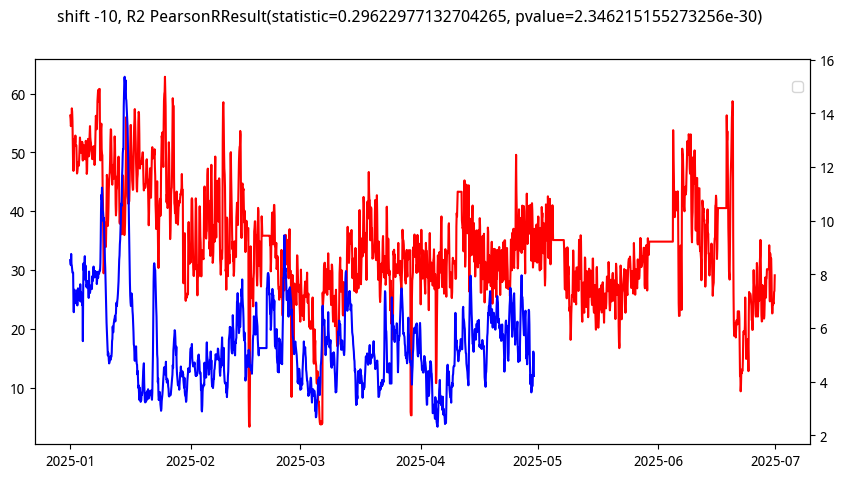

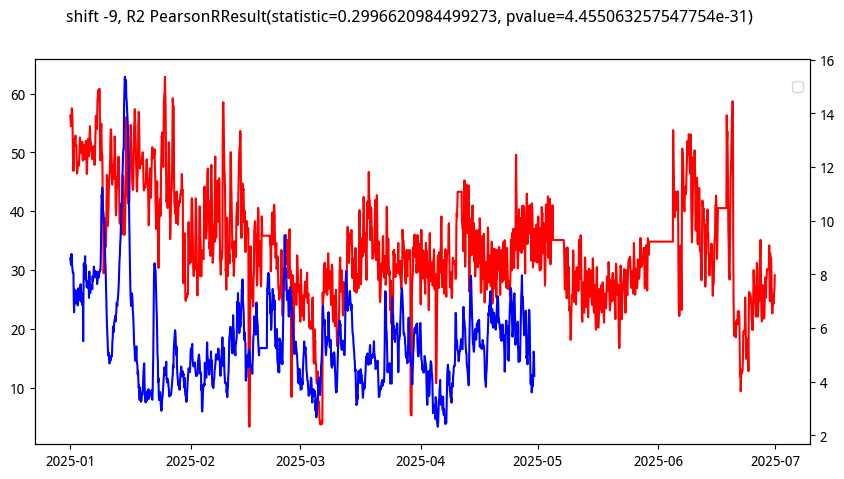

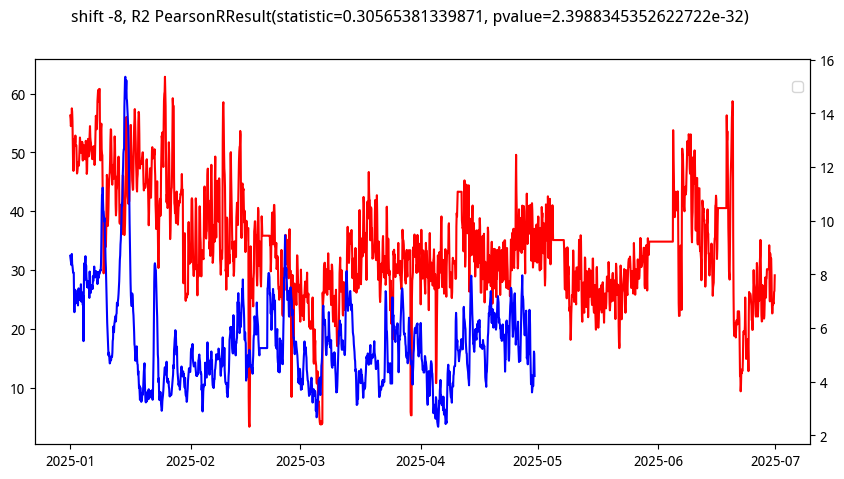

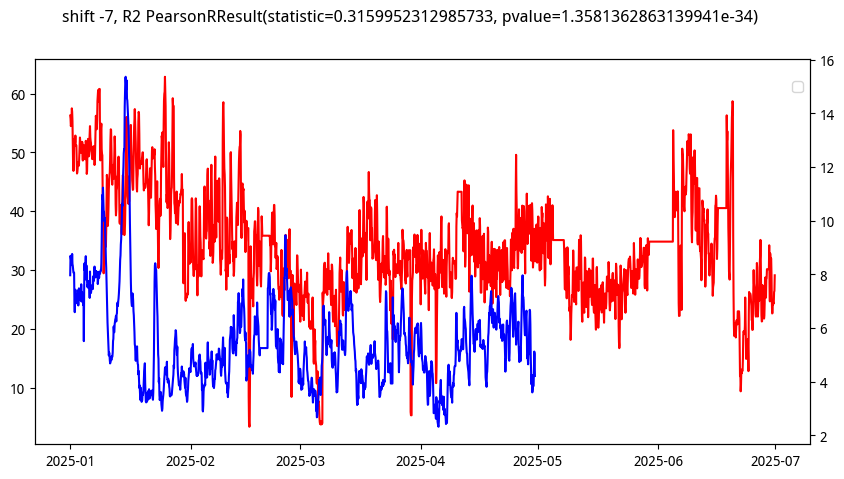

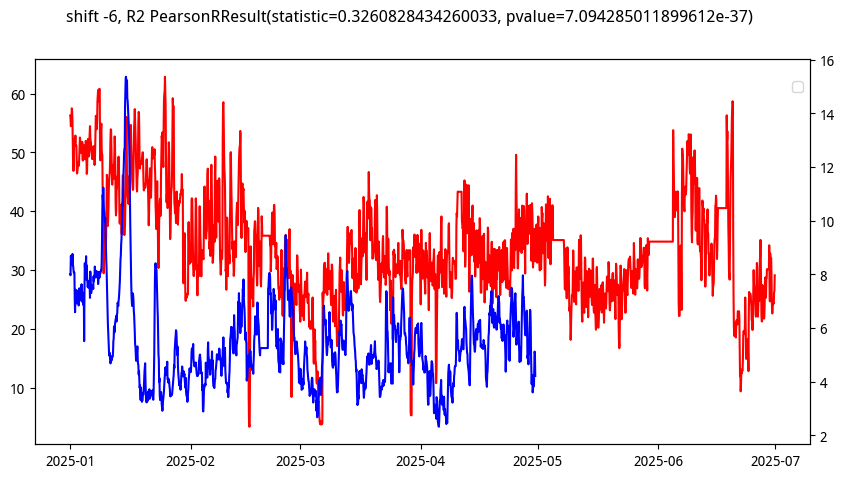

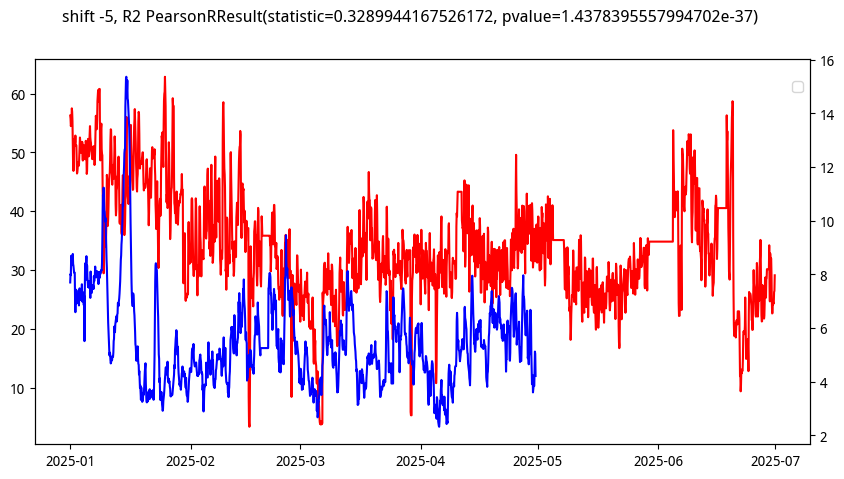

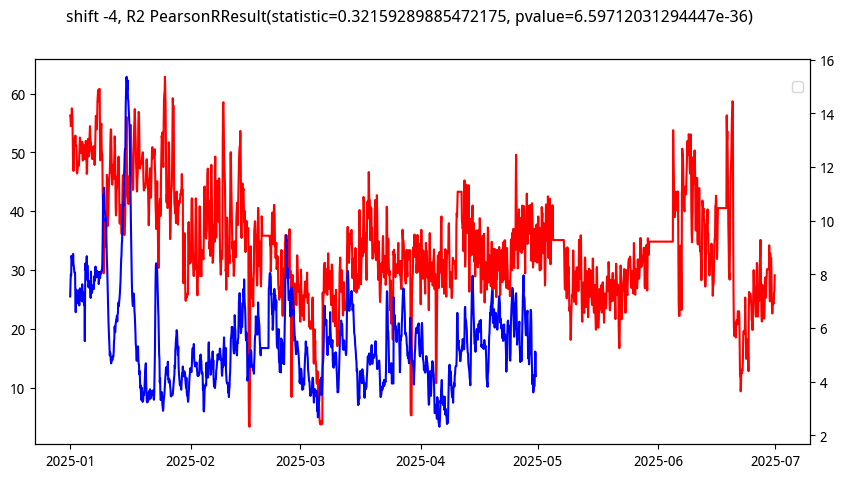

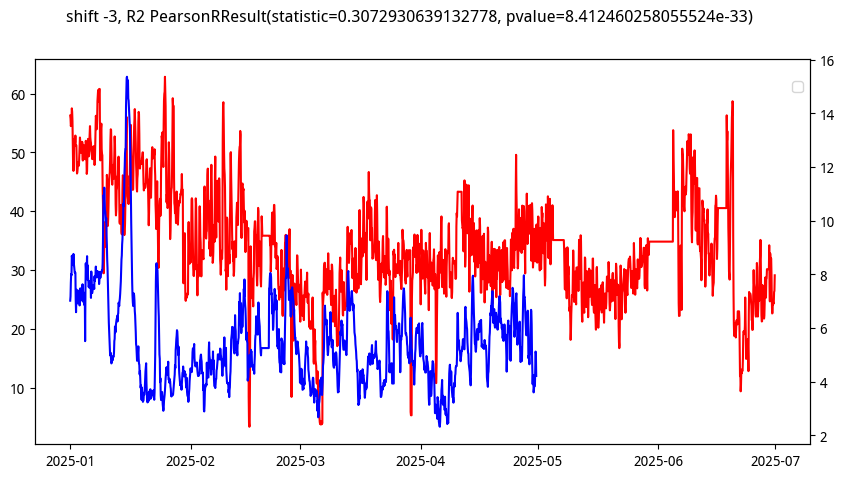

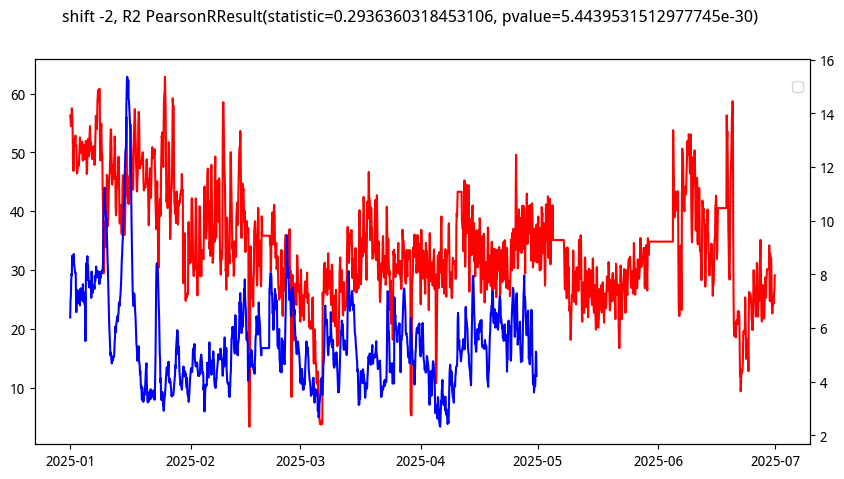

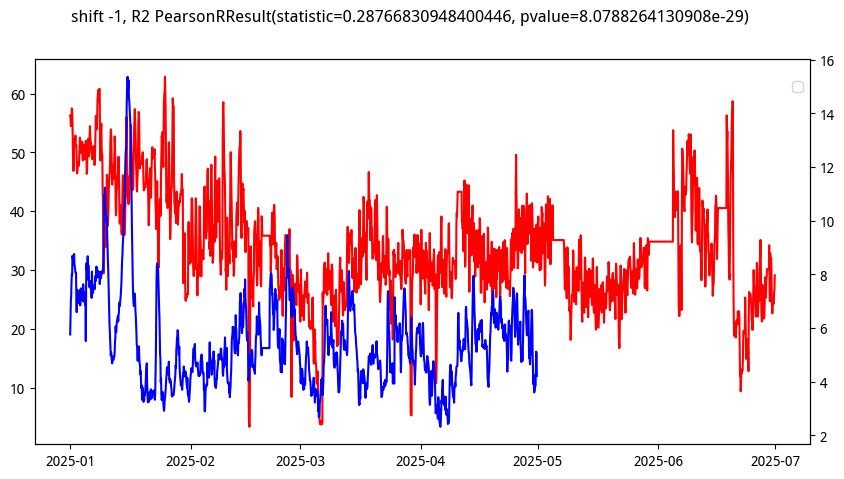

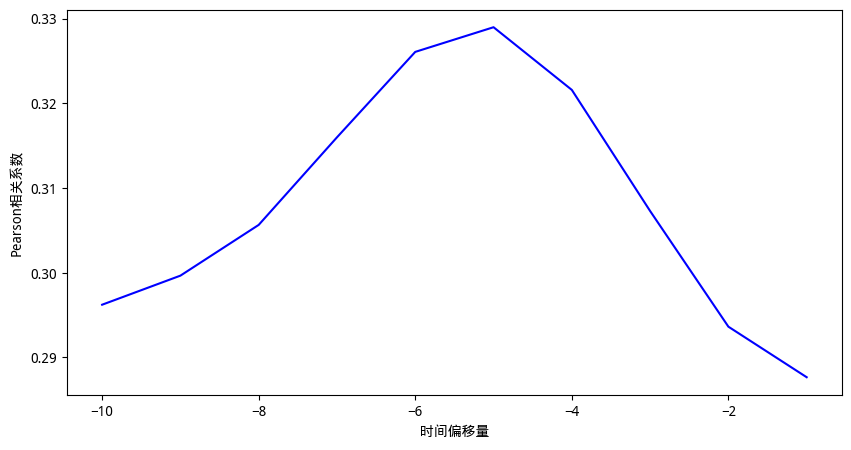

In [144]:
pr = []
for step in range(-10,0):
    df11 = df1.copy()
    for c in df11.columns:
        if '出水' in c:
            df11[c] = df11[c].shift(step)

    fig,ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(df11['进水TN'],c='r')
    ax2 = ax1.twinx()
    ax2.plot(df11['出水TN'],c='b')    
    fig.legend(bbox_to_anchor=(0.9, 0.85)) 
    df11 = df11[(~df11['进水TN'].isnull()) & (~df11['出水TN'].isnull())]
    fig.suptitle(f"shift {step}, R2 {pearsonr(df11['进水TN'],df11['出水TN'])}")
    
    pr.append(pearsonr(df11['进水TN'],df11['出水TN'])[0])

fig,ax1 = plt.subplots(figsize=(10,5))
ax1.plot(list(range(-10,0)),pr,c='blue')
ax1.set_ylabel('Pearson相关系数')
ax1.set_xlabel('时间偏移量')
fig.savefig('Pearson相关系数.jpg')

### DTW确定滞后时间

In [187]:
from scipy.spatial.distance import euclidean
from dtw import dtw

def calculate_time_lag(x,y,window_size):
    # 计算dtw距离和路径
    distance,path = dtw(x,y,dist=euclidean,radius=8,window_type='sakoechiba',window_args={'window_size': window_size})
    
    # 提取路径中的索引
    path_x = np.array([p[0] for p in path])
    path_y = np.array([p[1] for p in path])
    
    # 计算路径的平均斜率，从中提取时间滞后
    start_lag = path_y[0] - path_x[0]
    
    end_lag = path_y[-1] - path_x[-1]
    
    slope,intercept = np.polyfit(path_x,path_y,1)
    avg_lag = int(intercept)
    
    return path_x,path_y,avg_lag

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [204]:
df11 = df1.copy()
df11['进水TN'] = df11['进水TN'].rolling(window=5,center=True).mean()
df11 = df11[(~df11['进水TN'].isnull()) & (~df11['出水TN'].isnull())]
x = df11['进水TN'].values.reshape(-1,1)
y = df11['出水TN'].values.reshape(-1,1)
alignment = dtw(x,y,window_type='sakoechiba',window_args={'window_size':15})

In [205]:
alignment.index1

array([   0,    1,    2, ..., 1436, 1437, 1437])

In [206]:
alignment.index2

array([   0,    0,    0, ..., 1436, 1436, 1437])

In [207]:
slope,intercept = np.polyfit(alignment.index1,alignment.index2,1)
avg_lag = int(intercept)
avg_lag

-1

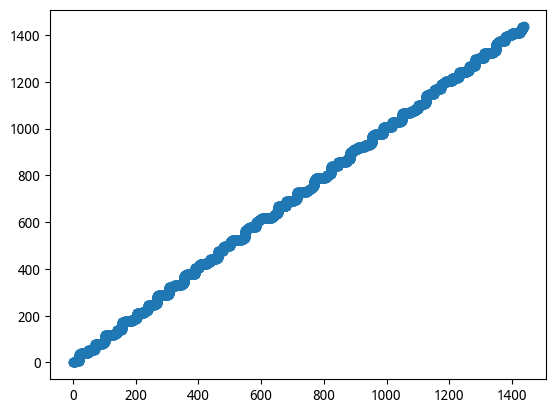

In [208]:
plt.scatter(alignment.index1,alignment.index2)

In [209]:
(alignment.index1-alignment.index2).max()

15

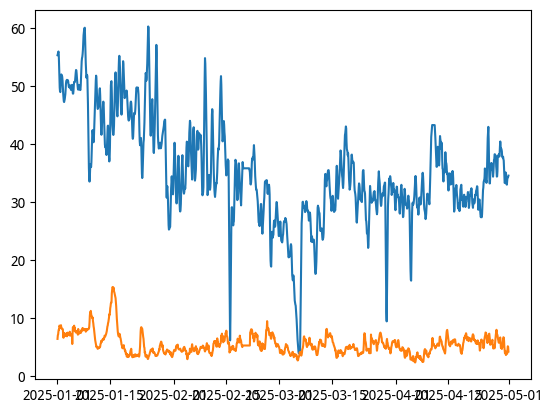

In [210]:
plt.plot(df11['进水TN'])
plt.plot(df11['出水TN'])

### 设置时间滞后为-5

In [11]:
df11 = df1.copy()
for c in df11.columns:
    if '出水' in c:
        df11[c] = df11[c].shift(-5)
df11

,进水COD,进水TP,进水NH3-N,进水TN,出水COD,出水TP,出水NH3-N,出水TN
日期时间,,,,,,,,
2025-01-01 00:00:00,171.201,3.369,43.253,56.253,11.080,0.177,0.023,7.699
2025-01-01 02:00:00,174.295,3.338,43.509,55.771,10.627,0.181,0.019,8.012
2025-01-01 04:00:00,177.408,3.222,43.092,54.463,10.699,0.179,0.020,7.968
2025-01-01 06:00:00,178.837,3.356,43.350,54.779,9.123,0.165,0.009,8.693
2025-01-01 08:00:00,190.300,3.454,44.209,55.591,9.553,0.162,0.015,8.596
...,...,...,...,...,...,...,...,...
2025-06-30 14:00:00,49.078,1.418,22.034,24.490,NaN,NaN,NaN,NaN
2025-06-30 16:00:00,82.177,1.133,19.784,24.376,NaN,NaN,NaN,NaN
2025-06-30 18:00:00,60.770,1.509,23.065,26.311,NaN,NaN,NaN,NaN


# LSTM

In [16]:
df12 = df11.resample('D').sum().loc['2025-02-13':'2025-04-29',:]
df12

,进水COD,进水TP,进水NH3-N,进水TN,出水COD,出水TP,出水NH3-N,出水TN
日期时间,,,,,,,,
2025-02-13,2370.010,40.928,433.089,549.692,166.362,0.809,0.222,75.956
2025-02-14,1615.385,54.257,375.452,489.118,150.936,0.804,0.290,81.909
2025-02-15,1563.844,12.457,288.262,375.956,198.335,0.599,0.191,59.496
2025-02-16,1023.627,15.744,204.414,269.659,231.006,0.616,0.177,57.236
2025-02-17,1332.585,22.486,307.403,399.793,162.238,0.570,0.184,66.370
...,...,...,...,...,...,...,...,...
2025-04-25,1846.422,34.052,344.695,448.103,119.011,0.942,0.183,75.537
2025-04-26,1747.119,31.469,323.971,424.252,111.178,0.920,0.185,64.070
2025-04-27,1787.422,34.757,344.482,443.524,107.553,1.052,0.175,81.449


In [18]:
df22 = df21.loc['2025-02-13':'2025-04-29',:]
df22

,加药累计流量\北池碳源,加药累计流量\南池碳源,加药累计流量\北池PAC,加药累计流量\南池PAC,加药累计流量\北池PAM,加药累计流量\南池PAM
日期时间,,,,,,
2025-02-13,0.00,0.00,0.95,0.0,0.00,10.16
2025-02-14,0.00,0.00,0.95,0.0,0.00,10.33
2025-02-15,0.00,0.00,0.90,0.0,0.00,10.15
2025-02-16,NaN,NaN,0.99,NaN,NaN,11.45
2025-02-17,0.00,0.00,1.00,0.0,0.00,0.00
...,...,...,...,...,...,...
2025-04-25,8.42,8.68,1.28,0.0,15.97,16.27
2025-04-26,8.20,8.97,1.13,0.0,15.23,14.79
2025-04-27,8.31,8.45,1.45,0.0,15.81,14.62


In [20]:
df32 = df31.resample('D').sum().loc['2025-02-13':'2025-04-29',:]
df32

,累积流量数据\出水累计流量,累积流量数据\进水累计流量
日期时间,,
2025-02-13,23253.25,26592.75
2025-02-14,27780.50,30762.00
2025-02-15,24852.50,26017.25
2025-02-16,23856.75,27236.00
2025-02-17,24162.25,26029.75
...,...,...
2025-04-25,26514.50,30097.50
2025-04-26,24921.50,24867.50
2025-04-27,25141.50,27621.50


## inputs & outputs

In [22]:
# 模型输入输出
x = pd.concat([df12.loc[:,'进水COD':'出水TN'],df32['累积流量数据\进水累计流量']],axis=1)
x.drop(columns=['进水TP','出水COD','出水TP','出水NH3-N'],inplace=True)
x

,进水COD,进水NH3-N,进水TN,出水TN,累积流量数据\进水累计流量
日期时间,,,,,
2025-02-13,2370.010,433.089,549.692,75.956,26592.75
2025-02-14,1615.385,375.452,489.118,81.909,30762.00
2025-02-15,1563.844,288.262,375.956,59.496,26017.25
2025-02-16,1023.627,204.414,269.659,57.236,27236.00
2025-02-17,1332.585,307.403,399.793,66.370,26029.75
...,...,...,...,...,...
2025-04-25,1846.422,344.695,448.103,75.537,30097.50
2025-04-26,1747.119,323.971,424.252,64.070,24867.50
2025-04-27,1787.422,344.482,443.524,81.449,27621.50


In [23]:
y = df22['加药累计流量\北池碳源']
y

日期时间
2025-02-13    0.00
2025-02-14    0.00
2025-02-15    0.00
2025-02-16     NaN
2025-02-17    0.00
              ... 
2025-04-25    8.42
2025-04-26    8.20
2025-04-27    8.31
2025-04-28    9.60
2025-04-29    9.74
Name: 加药累计流量\北池碳源, Length: 76, dtype: float64

In [24]:
x = x[~y.isnull()]
y = y[~y.isnull()]
y

日期时间
2025-02-13    0.00
2025-02-14    0.00
2025-02-15    0.00
2025-02-17    0.00
2025-02-18    0.00
              ... 
2025-04-25    8.42
2025-04-26    8.20
2025-04-27    8.31
2025-04-28    9.60
2025-04-29    9.74
Name: 加药累计流量\北池碳源, Length: 75, dtype: float64

## normalize

In [32]:
n = int(len(x) * 0.8)
x_train,x_test = x.iloc[0:n,:],x.iloc[n:,:]
y_train,y_test = y.iloc[0:n],y.iloc[n:]

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train) # fit: 计算均值标准差，transform:利用统计量进行标准化
x_test_scaled = scaler.transform(x_test) # 不再计算均值标准差，仅在训练集上拟合

## split train & test dataset

In [33]:
from torch.utils.data import Dataset,DataLoader
import torch

class waterTreatmentDataset(Dataset):
    def __init__(self,data,target,window_size=3):
        self.x,self.y = self.create_sequence(data,target,window_size)
    
    def create_sequence(self,data,target,window_siez):
        x_seq,y_seq = [],[]
        for i in range(len(data)-window_size):
            window = data[i:i+window_size]
            target_val = target[i+window_size]
            x_seq.append(window)
            y_seq.append(target_val)
        return torch.tensor(x_seq,dtype=torch.float32),torch.tensor(y_seq,dtype=torch.float32)
    
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self,idx):
        return self.x[idx],self.y[idx]

window_size = 3
train_dataset = waterTreatmentDataset(x_train_scaled,y_train,window_size)
test_dataset = waterTreatmentDataset(x_test_scaled,y_test,window_size)

batch_size = 32
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

## training

Epoch [10/200], Train Loss: 6.0076, Test Loss: 6.9222, LR: 0.010000
Epoch [20/200], Train Loss: 6.3868, Test Loss: 4.4179, LR: 0.002500
Epoch [30/200], Train Loss: 5.7994, Test Loss: 4.8002, LR: 0.001250
Epoch [40/200], Train Loss: 4.2804, Test Loss: 4.4224, LR: 0.000313
Epoch [50/200], Train Loss: 5.0769, Test Loss: 4.4736, LR: 0.000078
Epoch [60/200], Train Loss: 4.4642, Test Loss: 4.4884, LR: 0.000039
Epoch [70/200], Train Loss: 4.6572, Test Loss: 4.4901, LR: 0.000010
Epoch [80/200], Train Loss: 5.5301, Test Loss: 4.4937, LR: 0.000002
Epoch [90/200], Train Loss: 4.9449, Test Loss: 4.4950, LR: 0.000001
Epoch [100/200], Train Loss: 5.6262, Test Loss: 4.4950, LR: 0.000000
Epoch [110/200], Train Loss: 4.9653, Test Loss: 4.4950, LR: 0.000000
Epoch [120/200], Train Loss: 4.5428, Test Loss: 4.4950, LR: 0.000000
Epoch [130/200], Train Loss: 5.0081, Test Loss: 4.4950, LR: 0.000000
Epoch [140/200], Train Loss: 4.4233, Test Loss: 4.4950, LR: 0.000000
Epoch [150/200], Train Loss: 5.8918, Test L

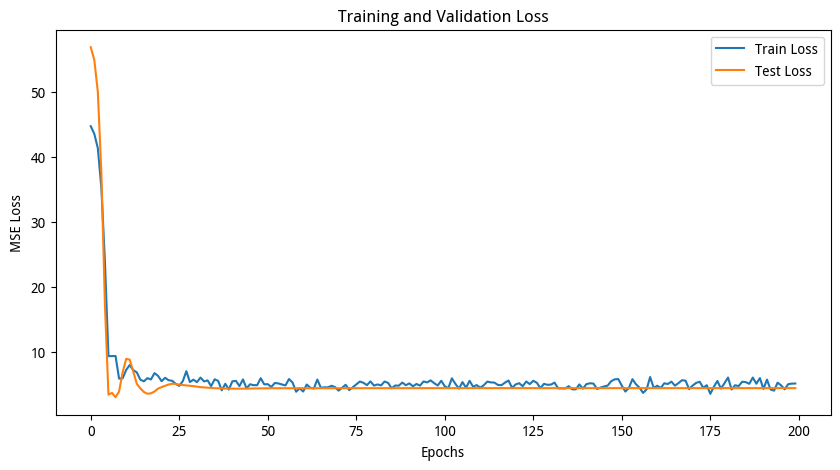

In [59]:
import torch.nn as nn
import torch.optim as optim

class carbonLSTMModel(nn.Module):
    def __init__(self,input_size,hidden_size=64,num_layers=2,output_size=1):
        super(carbonLSTMModel,self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # lstm层
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True, # 输入形状（batch,seq_len,features）
            dropout = 0.2
        )
        
        # 全连接层
        self.fc = nn.Sequential(
            nn.Linear(hidden_size,32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32,output_size)
        )
        
    def forward(self,x):
        # 初始化隐藏状态
        h0 = torch.zeros(self.num_layers,x.size(0),self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers,x.size(0),self.hidden_size).to(x.device)
        
        # lstm前向传播
        out,(hn,cn) = self.lstm(x,(h0,c0))
        
        # 只取最后一个时间步的输出
        out = out[:, -1, :]
        
        # 全连接层
        out = self.fc(out)
        
        return out
    
def train_model(model,train_loader,test_loader,epochs=100,lr=0.01):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(),lr=lr)
    # 在监测的指标（如验证损失）停止改善时自动降低学习率
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                     'min', # 监测指标的目标：最小化
                                                     patience=5, # 容忍多少个 epoch 没有改善
                                                     factor=0.5) # 学习率降低的因子（新学习率 = 旧学习率 * factor）
    
    train_losses,test_losses = [],[]
    for epoch in range(epochs):
        # 训练阶段
        model.train()
        train_loss = 0
        for batch_x,batch_y in train_loader:
            batch_x,batch_y = batch_x.to(device),batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs.squeeze(),batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # 验证阶段
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for batch_x,batch_y in test_loader:
                batch_x,batch_y =  batch_x.to(device),batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs.squeeze(),batch_y)
                test_loss += loss.item()
        
        avg_test_loss = test_loss / len(test_loader)
        test_losses.append(avg_test_loss)
        scheduler.step(avg_test_loss) # ReduceLROnPlateau 调度器会根据验证集指标（如损失）的变化自动降低学习率
        
        # 打印训练进度
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], '
                  f'Train Loss: {avg_train_loss:.4f}, '
                  f'Test Loss: {avg_test_loss:.4f}, '
                  f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
        
    # 绘制损失曲线
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.show()
    
    return model

# 模型初始化
input_size = x_train_scaled.shape[1] # 特征数量
model = carbonLSTMModel(input_size=input_size)

# 开始训练
trained_model = train_model(model,train_loader,test_loader,epochs=200)

## evaluation

Test Metrics:
RMSE: 2.1201
MAE: 1.8356
MAPE: 25.87%
R²: -0.5014


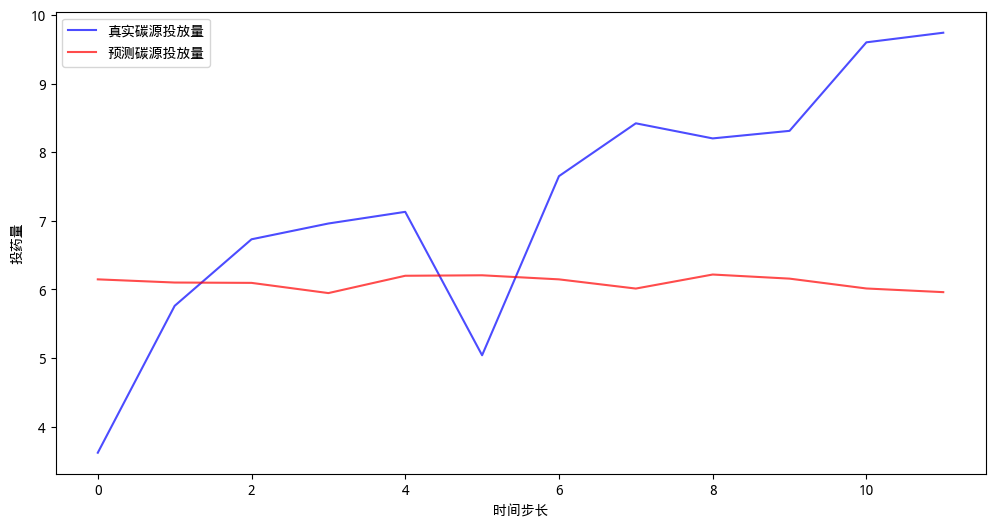

<Figure size 640x480 with 0 Axes>

In [60]:
def evaluate_model(model,test_loader):
    device = next(model.parameters()).device
    model.eval()
    
    actuals,predictions = [],[]
    with torch.no_grad():
        for batch_x,batch_y in test_loader:
            batch_x =  batch_x.to(device)
            outputs = model(batch_x).squeeze().cpu().numpy()
            
            predictions.extend(outputs)
            actuals.extend(batch_y.numpy())
    
    # 计算指标
    actuals = np.array(actuals)
    predictions = np.array(predictions)
    
    # RMSE
    rmse = np.sqrt(np.mean((actuals - predictions) ** 2))
    # MAE
    mae = np.mean(np.abs(actuals - predictions))
    # MAPE (避免除零)
    mask = actuals != 0
    mape = np.mean(np.abs((actuals[mask] - predictions[mask]) / actuals[mask])) * 100
    # R²
    r2 = 1 - np.sum((actuals - predictions) ** 2) / np.sum((actuals - np.mean(actuals)) ** 2)
    
    print(f'Test Metrics:')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAE: {mae:.4f}')
    print(f'MAPE: {mape:.2f}%')
    print(f'R²: {r2:.4f}')
    
    # 绘制实际 vs 预测
    plt.figure(figsize=(12, 6))
    plt.plot(actuals, label='真实碳源投放量', alpha=0.7,c='b')
    plt.plot(predictions, label='预测碳源投放量', alpha=0.7,c='r')
#     plt.title('Actual vs Predicted Carbon Source Dosing')
    plt.xlabel('时间步长')
    plt.ylabel('投药量')
    plt.legend()
    plt.show()
    plt.savefig('lstm预测.jpg')
    
    return actuals, predictions

# 评估模型
actuals, predictions = evaluate_model(trained_model, test_loader)

Test Metrics:
RMSE: 2.0536
MAE: 1.5027
MAPE: 20.92%
R²: 0.1149


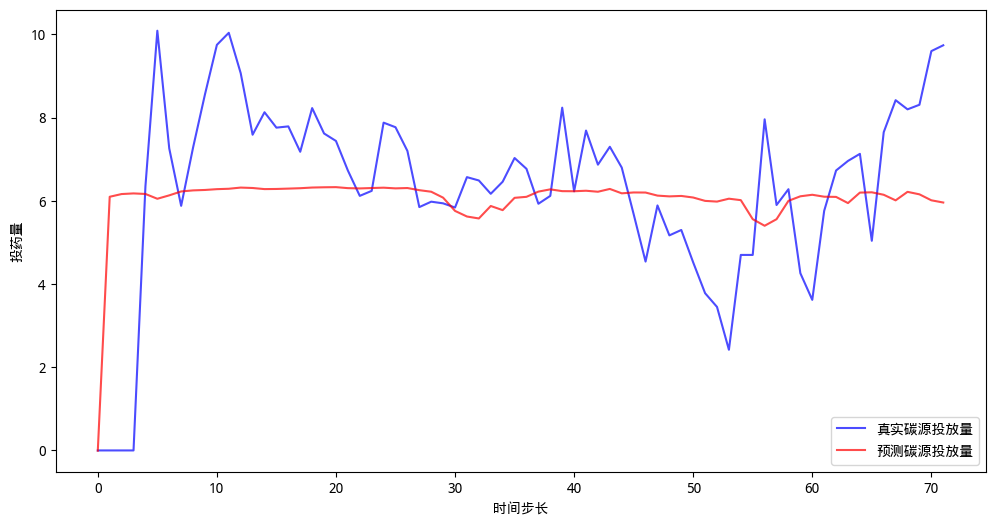

<Figure size 640x480 with 0 Axes>

In [61]:
# 全数据预测
dataset = waterTreatmentDataset(scaler.transform(x),y)
batch_size = 32
data_loader = DataLoader(dataset,batch_size=batch_size,shuffle=False)

actuals, predictions = evaluate_model(trained_model, data_loader)